# Data Exploration & Feature Engineering

This notebook handles the cleaning and exploratory data analysis (EDA) of the Sloan Digital Sky Survey (SDSS) spectroscopic galaxy dataset. The primary goal is to map the distribution of galaxies across various color indices and identify highly degenerate regions in color-color space which complicate photometric redshift estimation. We will also save the processed data for use in subsequent modeling notebooks.

In [1]:
import numpy as np
import pandas as pd
import pickle
import plotly.express as px

from matplotlib import pyplot as plt
from scipy.ndimage import uniform_filter
from matplotlib.ticker import MultipleLocator
from astroML.datasets import fetch_sdss_specgals
from astroML.utils.decorators import pickle_results
from sklearn.model_selection import train_test_split

## 1. Data Fetching and Feature Engineering

We begin by loading the raw SDSS spectroscopic galaxy dataset and engineering our primary features. For galaxies in SDSS, the `modelMag` columns are universally considered the standard for deriving photometric colors because they account for the extended physical profiles of galaxies. By subtracting adjacent magnitude bands, we compute four primary color indices: $u-g$, $g-r$, $r-i$, and $i-z$. These specific adjacent color differences are crucial as they capture significant spectral features, such as the 4000 Angstrom break, moving through the photometric filter bands as the galaxy is redshifted.

In [2]:
# Get the data
data = fetch_sdss_specgals()
df = pd.DataFrame(data)
print("Raw data shape:", data.shape)

# 1. Calculate the Color Indices
# For galaxies in SDSS, you should always use the 'modelMag' columns
df['u-g'] = df['modelMag_u'] - df['modelMag_g']
df['g-r'] = df['modelMag_g'] - df['modelMag_r']
df['r-i'] = df['modelMag_r'] - df['modelMag_i']
df['i-z'] = df['modelMag_i'] - df['modelMag_z']

Raw data shape: (661598,)


## 2. Data Cleaning & Train/Test Splitting

Photometric redshift pipelines are very sensitive to photometric noise and magnitude measurement errors. Therefore, we filter out any observations with significant measurement errors to ensure our models train on a high-quality dataset. Additionally, we exclude the very local universe blob (galaxies with $z < 0.02$) because their doppler redshift dominate their cosmological redshift, which adds unwanted noise. The cleaned dataset is then split into training, validation, and testing subsets to ensure our models can be evaluated properly without data leakage.

In [3]:
# --------------------
# Main Dataset Cleaning & Splitting
# --------------------

# Filtering Parameters
mag_err = 1
z_min = 0.02

# Filter the dataset
df_clean = df[
    (df['modelMagErr_u'] < mag_err) &
    (df['modelMagErr_g'] < mag_err) &
    (df['modelMagErr_r'] < mag_err) &
    (df['modelMagErr_i'] < mag_err) &
    (df['modelMagErr_z'] < mag_err) &
    (df['z'] > z_min)
]

# Define the X and y datasets
X = df_clean[['u-g', 'g-r', 'r-i', 'i-z']]
y = df_clean['z']

# Define the file path
file_path = f'data/dataset_clean.pkl'

# Using pickle to save the splits locally
@pickle_results(file_path)
def split_data(X_data, y_data):
    X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Run the function to generate and save the splits
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

# Save the full dataset (without splits)
with open('data/full_dataset_clean.pkl', 'wb') as file:
    pickle.dump(df_clean, file)

@pickle_results: using precomputed results from 'data/dataset_clean.pkl'


## 3. Redshift Distribution

Visualizing the distribution of our target variable, spectroscopic redshift ($z$), provides immediate insight into the sample's demographics. The spectroscopic redshift acts as our "ground truth" target because it is measured directly from spectral emission and absorption lines, which is highly accurate but computationally and observationally expensive. The histogram helps us identify the domain where our training data is most dense, which typically implies where our model predictions will be the most reliable and confident.

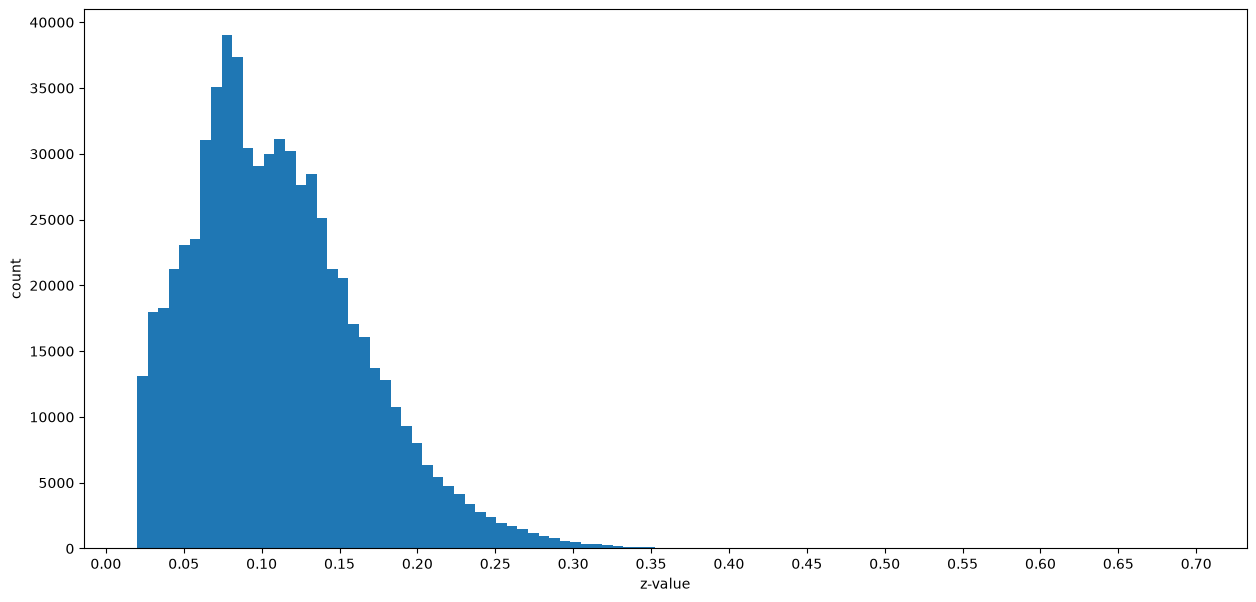

In [4]:
# --------------------
# Z-Value Distribution
# --------------------

# Create figure and axes objects
fig, ax = plt.subplots(figsize=(15,7))

# Plot the histogram
ax.hist(df['z'], bins=100)

# Force the x-axis to show a tick every 0.05 units
ax.xaxis.set_major_locator(MultipleLocator(0.05))

ax.set_xlabel("z-value")
ax.set_ylabel("count")
plt.show()

## 4. Degenerate Regions in Color-Color Space

Certain regions within color-color space suffer from severe degeneracy, a phenomenon where a very small volume in color-space maps to a widely dispersed range of physical redshifts. Identifying these regions is critical because they represent fundamental limits to photometric redshift accuracy where even the most complex models will inherently struggle. Here, we calculate the standard deviation of the redshift target within 2D color grid cells to map out these problem areas. If the standard deviation is extremely high within a tight color boundary, it strongly signals a degenerate region.

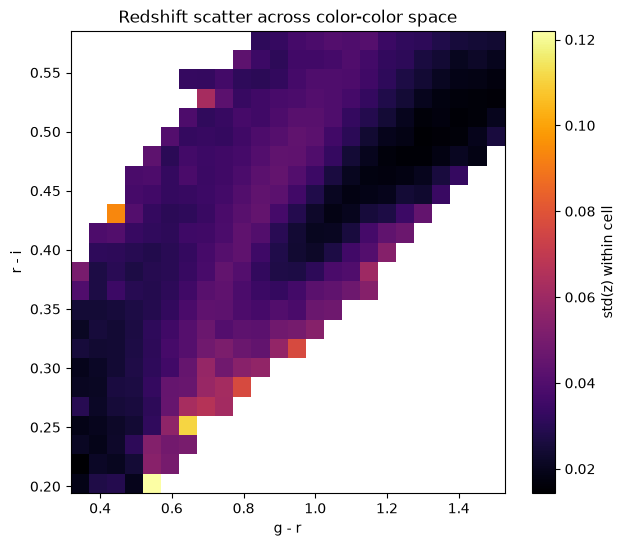

In [5]:
# ----------
# Finding Degenerate Regions 
# ----------

with open('data/full_dataset_clean.pkl', 'rb') as file:
    full_df = pickle.load(file)
    
g_r = full_df['g-r'].values
r_i = full_df['r-i'].values
z = full_df['z'].values

# Avoiding outliers in data
g_r_low, g_r_high = np.percentile(g_r, [1, 99])
r_i_low, r_i_high = np.percentile(r_i, [1, 99])

bins = 25
g_r_bins = np.linspace(g_r_low, g_r_high, bins)
r_i_bins = np.linspace(r_i_low, r_i_high, bins)

# Computer std(z) per cell of grid
z_std_cell = np.full((len(g_r_bins)-1, len(r_i_bins)-1), np.nan)
count_cell = np.zeros_like(z_std_cell)

# Building a 2D histogram and compute std(z) for each cell in grid
for i in range(len(g_r_bins) - 1):
    for j in range(len(r_i_bins) - 1):
        mask = (
            (g_r >= g_r_bins[i]) & (g_r < g_r_bins[i+1]) &
            (r_i >= r_i_bins[j]) & (r_i < r_i_bins[j+1])
        )
        n = mask.sum()
        count_cell[i,j] = n
        if(n >= 20):
            z_std_cell[i,j] = z[mask].std()

# Plot
plt.figure(figsize=(7, 6))
plt.imshow(z_std_cell.T, origin='lower', aspect='auto', cmap='inferno',
           extent=[g_r_bins[0], g_r_bins[-1], r_i_bins[0], r_i_bins[-1]])
plt.colorbar(label='std(z) within cell')
plt.xlabel('g - r')
plt.ylabel('r - i')
plt.title('Redshift scatter across color-color space')
plt.show()

### 4.1 Locating the Top Degenerate Boundaries

To quantitatively pinpoint the biggest severely degenerate regions, we apply a 2D smoothing filter over our standard deviation grid. This smoothing step mitigates the effect of isolated, noisy cells with low sample counts. By sorting and extracting the top five cells with the highest smoothed redshift scatter, we explicitly define the exact color boundaries where photometric redshift estimation is fundamentally limited. Identifying these specific intervals allows us to test our models' uncertainty quantification explicitly within this problematic area later on.

In [6]:
# Search for a degenerate region
z_std_masked = np.where(count_cell >= 20, z_std_cell, np.nan)
z_std_smooth = uniform_filter(np.nan_to_num(z_std_masked), size=3)
valid_smooth = uniform_filter((count_cell >= 20).astype(float), size=3)
z_std_smooth = np.divide(z_std_smooth, valid_smooth, out=np.full_like(z_std_smooth, np.nan), where=valid_smooth > 0.5)

# Print the top 5 regions
flat_sorted = np.argsort(np.nan_to_num(z_std_smooth, nan=-1).ravel())[::-1][:5]
table_data = []
for rank, idx in enumerate(flat_sorted, start=1):
    i, j = np.unravel_index(idx, z_std_smooth.shape)
    
    table_data.append({
        "Rank": rank,
        "g-r Range": f"[{g_r_bins[i]:.3f}, {g_r_bins[i+1]:.3f}]",
        "r-i Range": f"[{r_i_bins[j]:.3f}, {r_i_bins[j+1]:.3f}]",
        "Std Dev (Smoothed)": round(z_std_smooth[i, j], 6),
        "Count (N)": int(count_cell[i, j])
    })

# Convert to a DataFrame and display it
results_df = pd.DataFrame(table_data)
display(results_df.style.hide(axis='index'))

Rank,g-r Range,r-i Range,Std Dev (Smoothed),Count (N)
1,"[0.671, 0.721]","[0.243, 0.260]",0.070474,19
2,"[0.671, 0.721]","[0.260, 0.276]",0.067012,43
3,"[0.721, 0.772]","[0.260, 0.276]",0.065139,25
4,"[0.620, 0.671]","[0.227, 0.243]",0.063178,27
5,"[0.570, 0.620]","[0.211, 0.227]",0.063081,23


## 5. Visualizing the Redshift Track

By filtering for only the highest-quality observations, we can clearly visualize how galaxy colors relate to redshift. The data forms a distinct, curving track through the different color combinations rather than a simple straight line. Viewing these relationships in 2D and 3D plots shows exactly why basic linear models struggle with this task, as the data frequently bends and overlaps itself. Seeing this complex shape explains why we must rely on advanced, non-linear machine learning models in the next notebooks.

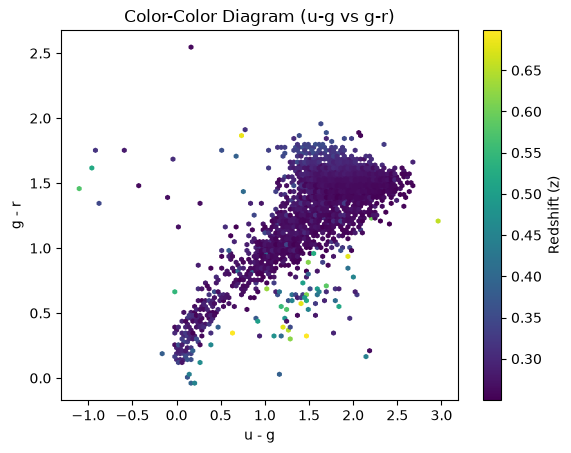

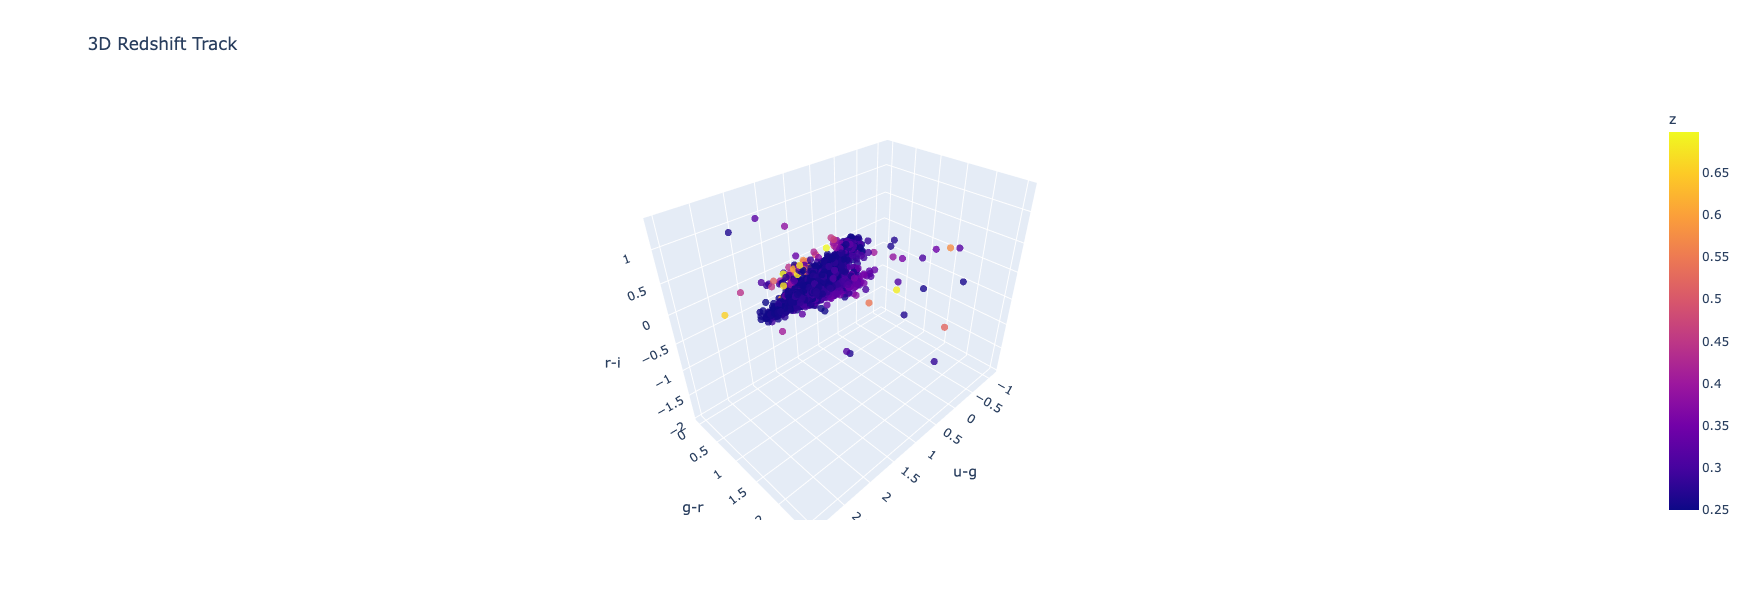

In [7]:
# --------------------
# Visualization Subsetting
# --------------------
model_mag_error = 0.25

# We use stricter error bounds to isolate the redshift track structure
df_plot = df[
    (df['modelMagErr_u'] < model_mag_error) &
    (df['modelMagErr_g'] < model_mag_error) &
    (df['modelMagErr_r'] < model_mag_error) &
    (df['modelMagErr_i'] < model_mag_error) &
    (df['modelMagErr_z'] < model_mag_error) &
    (df['z'] > 0.25) # Filter the low-z blob for clarity
]

# 2D Hexbin
hb = plt.hexbin(df_plot['u-g'], df_plot['g-r'], C=df_plot['z'], cmap='viridis')
plt.xlabel('u - g')
plt.ylabel('g - r')
plt.title('Color-Color Diagram (u-g vs g-r)')
cb = plt.colorbar(hb)
cb.set_label('Redshift (z)')
plt.show()

# 3D Interactive Plot
fig = px.scatter_3d(
    df_plot, 
    x='u-g', 
    y='g-r', 
    z='r-i',
    color='z',
    color_continuous_scale='Plasma',
    title='3D Redshift Track'
)
fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_layout(width=800, height=600)
fig.show()